<h3>Importing my development version of ShadowGrouping</h3>

In [1]:
import sys, numpy as np, time, pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import matplotlib.pyplot as plt
from IPython.display import Image, display
from os import mkdir
from os.path import isdir, isfile
from pathlib import Path
from random import randrange
import json

# adding ShadowGrouping package to the system path
# SG_package_path = r"G:\\My Drive\\Work\\Research\\Numerics\\ShadowGrouping Code\\"
#SG_package_path = r"C:\Users\aebad\shadowgrouping\\"
SG_package_path = r"C:\Users\Abbas\Priori\\"
sys.path.insert(0, SG_package_path)
#savename = ".txt" # insert {mapping_name}
savepath = Path("generated_data/convexoptimization/")
savepath.mkdir(parents=True, exist_ok=True)
# defining path where Hamiltonians are stored
folder_Hamiltonians = SG_package_path + "Hamiltonians_v2\\"

In [2]:
from shadowgrouping_v2.measurement_schemes import L1_sampler, Derandomization
#from shadowgrouping.measurement_schemes import Shadow_Grouping
from shadowgrouping.measurement_schemes_Shadowupdate import Priori, Posteriori, Shadow_Grouping, Best_scheme_given_pool, Shadow_Grouping_STD
from shadowgrouping_v2.weight_functions import Bernstein_bound
from shadowgrouping_v2.energy_estimator import Energy_estimator, StateSampler, Sign_estimator
from shadowgrouping_v2.helper_functions import (
    setting_to_str, char_to_int, int_to_char, settings_to_dict, prepare_settings_for_numba, gaussian_weights, gaussian_random_paulis, uniform_weights, uniform_random_paulis,
    sample_obs_from_setting, setting_to_str, setting_to_obs_form, sample_obs_batch_from_setting_batch, sample_obs_batch_from_setting_batch_numba, bootstrap_rmse)
from shadowgrouping_v2.shadowgrouping_my_dev.helper_functions import combine_seed
from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state
from shadowgrouping_v2.guarantees import (
    get_epsilon_Bernstein, get_epsilon_Bernstein_no_restricted_validity, 
    get_epsilon_Bernstein_tighter, get_epsilon_Bernstein_tighter_no_restricted_validity, 
    get_epsilon_Bernstein_scalar, get_epsilon_Bernstein_scalar_no_restricted_validity,
    get_epsilon_Bernstein_scalar_tighter, get_epsilon_Bernstein_scalar_tighter_no_restricted_validity, 
    get_epsilon_Hoeffding_scalar, get_epsilon_Hoeffding_scalar_tighter, get_epsilon_Chebyshev_scalar, 
    get_epsilon_Chebyshev_scalar_tighter, get_epsilon_single_Hoeffding_plus_union_bound,
    get_epsilon_Chebyshev_scalar_numba, get_epsilon_Chebyshev_scalar_tighter_numba,
    get_epsilon_Hoeffding_scalar_numba, get_epsilon_Hoeffding_scalar_tighter_numba)
from guarantees.exact_covariances import covariance_matrix
from guarantees.guarantees import (get_epsilon_Chebyshev_scalar_tighter_numba, get_epsilon_Chebyshev_scalar_tightest_numba)
from shadowgrouping.poolgenerators import Priori_Pool , OGM_Pool, AEQUO_Pool, AEQUO_Pool_weightbased, OGM_NPBC

C:\Users\Abbas\AppData\Local\Temp\ipykernel_8780\21302587.py:10: NatureDeprecationWarning: The qiskit_nature.drivers.second_quantization package is deprecated as of version 0.5.0 and will be removed no sooner than 3 months after the release. Instead use the qiskit_nature.second_q.drivers package.
  from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state


<h3>Choosing molecule, basis set and fermion-to-qubit mapping</h3>

In [ ]:
molecule_name = "H2O" # choose one out of the molecules ['H2', 'H2_6-31g', 'LiH', 'BeH2', 'H2O', 'NH3']
mapping_name = "JW" # choose one out of ["JW","BK","Parity"]
if molecule_name == 'H2':
    basis_set = "6-31g"
else:
    basis_set = "sto3g"
num_qubits = {'H2': 8, 'LiH': 12, 'BeH2': 14, 'H2O': 14, "NH3": 16} # number of qubits in which Hamiltonian is defined
savename = molecule_name + "_molecule_" + mapping_name + "_" + basis_set
folder_OGM_settings = "OGM_probabilities/OGM_{}_{}{}.txt" # format string to fill in {molecule}x{qubit_number}x{mapping}

<h3>Import the original hamiltonian file</h3>

In [4]:
# ensure the folder exists
import os


assert os.path.isdir(folder_Hamiltonians), f"Path '{folder_Hamiltonians}' does not exist or is not a directory."
    # find folder matching molecule + basis name
available_folders = os.listdir(folder_Hamiltonians)
prefix = f"{molecule_name}_{basis_set}"
folder_name = None
for folder in available_folders:
    if folder.startswith(prefix):
        folder_name = folder
        break

assert folder_name is not None, f"File not found for molecule '{molecule_name}' and basis set '{basis_set}'."
full_folder_path = os.path.join(folder_Hamiltonians, folder_name)

    # look for encoding and energy file
available_files = os.listdir(full_folder_path)
    
    #print(f"full path to folder",full_folder_path)
file_name = None
file_energy = None
for file in available_files:
    if file.lower().startswith(mapping_name[:2].lower()) and "grouped" not in file:
        file_name = file
    elif file == "ExactEnergy.txt":
        file_energy = file

assert file_name is not None, f"File not found for encoding '{mapping_name}'."
assert file_energy is not None, "File not found for ground-state energy."
    
print(f"full path to file",os.path.join(full_folder_path, file_name))

full path to file C:\Users\Abbas\Priori\\Hamiltonians_v2\H2O_sto3g_14qubits\parity.txt


<h3>Loading Prior Information</h3>

In [5]:
# Loading Hamiltonian
observables, w, offset, E_GS, state = load_pauli_list(folder_Hamiltonians,molecule_name,basis_set,mapping_name,diagonalize=False)

# loading exact ground state
path_to_GS = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs.txt"
with open(path_to_GS, 'r') as f:
    data_string = f.read()
state = data_string.split('\n')
state = state[:len(state)-1]
for i in range(len(state)):
    state[i] = complex(state[i])
state = np.array(state)

# Loading exact ground state energy
path_to_GS_energy = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs_energy.txt"
with open(path_to_GS_energy, 'r') as f:
    data_string = f.read()
E_GS = float(data_string)
print(f"Exact ground state energy: {E_GS}")

# Calculating exact covariances

sanity = False
tightest = True

if tightest:
    path_to_cov_real = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\cov_real_" + mapping_name + ".npy"
    os.makedirs(os.path.dirname(path_to_cov_real), exist_ok=True)
    if os.path.exists(path_to_cov_real):
        print("Loading exact covariance matrix from file...")
        #loading exact covariance matrix from file
        cov_real = np.load(path_to_cov_real)
    else:
        # Computing exact representation of full covariance matrix
        exact_covariances = covariance_matrix(state, observables)
        #print(np.round(exact_covariances,3))
        cov_real = np.ascontiguousarray(((exact_covariances + exact_covariances.conj().T).real) * 0.5, dtype=np.float64)
        # Save the computed covariance matrix to file for future runs
        np.save(path_to_cov_real, cov_real)
        print(f"Saved exact covariance matrix to {path_to_cov_real}")
if sanity:
        # Sanity check: Computing total variance using full matrix representation of Hamiltonian
        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)
        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)
        exp_value_H = np.dot(np.conjugate(state), H_dot_state)
        var_H = exp_value_H2 - exp_value_H**2
        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian

Exact ground state energy: -83.59943020533544
Saved exact covariance matrix to C:\Users\Abbas\Priori\\Hamiltonians_v2\H2O_sto3g_14qubits\cov_real_Parity.npy


<h3>Setting Parameters for Simulation</h3>

In [6]:
Nreps = 100
eps = 0.01
delta = 0.33
Nrounds = 100000
sampling_seed    = int(randrange(1000000))
alpha = np.max(np.abs(w))/np.min(np.abs(w)) + np.min(np.abs(w))
state_sampler = StateSampler(state)

<h3>Generating measurement scheme using Shadow_Grouping OR Priori<h3>

In [ ]:
label = "SGP" # Select the pool generation method: "SGP" for Shadow Grouping, "PP" for Priori_Pool, "OGMP" for Overlapped Grouping, "AEP" for AEQUO_Pool, "AEWP" for AEQUO_Weighted_Pool, "OGM_NPBC" for OGM without periodic boundary conditions, "STD" for steady_state_budget_allocation.
if label == "SGP":
    methodname = "Shadow Grouping Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 10000
    method_1 = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator_1.reset()
    points = 5
    prev = 0
    rmse_values = []
    rmse_stds = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.propose_next_settings(n - prev)
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates = estimator_1.get_energy()
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": int(n), "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

if label == "PP":
    methodname = "Priori Pool"
    t_init_scheme_1 = time.time()
    method_1 = Priori_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)
    
if label == "OGMP":
    methodname = "Overlapped Grouping Pool"
    t_init_scheme_1 = time.time()
    # catch exception of missing data for OGM
    file = folder_OGM_settings.format(molecule_name,observables.shape[1],mapping_name.lower())
    if isfile(file):
        method_1 = OGM_Pool(observables,w,file)
        method_1.find_setting()
        t_end_scheme_1 = time.time()
        print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
        print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
        print(method_1.N_hits)
    else:
        print(f"File not found for OGM probabilities: {file}. Please run the OGM pool generation code to generate the required data.")


if label == "AEP":
    methodname = "AEQUO Pool"
    t_init_scheme_1 = time.time()
    method_1 = AEQUO_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)


if label == "AEWP":
    methodname = "AEQUO Weighted Pool"
    t_init_scheme_1 = time.time()
    method_1 = AEQUO_Pool_weightbased(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)


if label == "OGM_NPBC":
    methodname = "OGM without periodic boundary conditions Pool"
    t_init_scheme_1 = time.time()
    method_1 = OGM_NPBC(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)

if label == "STD":
    methodname = "Steady State Budget Allocation Pool"
    Nreps_SGP = 100
    Nrounds_SGP = 10000
    method_1 = Shadow_Grouping_STD(observables,w,eps,Bernstein_bound(alpha=alpha)(), save_scheme=False,handle_ties=True,compute_N_hits_pairs=True)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP, compat_type='qwc', qubit_connectivity=None)
    estimator_1.reset()
    points = 1
    prev = 0
    rmse_values = []
    rmse_stds = []
    t_init_scheme_1 = time.time()
    sample_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds_SGP), max(points, 2))).astype(int))
    if points == 1:
        sample_points = np.array([Nrounds_SGP])
    for n in sample_points:
        estimator_1.steady_state_budget_allocation(num_steps= (n - prev), beta=0.01, verbose=True)
        estimator_1.measure_and_get_running_avgs(seed=sampling_seed)
        energy_estimates_1 = estimator_1.get_energy()
        print("energy estimates:", energy_estimates_1)
        print(f"energy_estimates mean: {np.mean(energy_estimates_1):.6f}, std: {np.std(energy_estimates_1):.6f}")
        rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
        energy_estimates_1, E_GS, n_boot=20000, ci=0.67)
        rmse_values.append({"n": n, "rmse": rmse, "std": rmse_se})
        print(f"Shots: {n} | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
        prev = n
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
[W update] round=280  FIRST_WINDOW done (len=280)  S_eff=280.000  -> W=2579
[W update] round=2859  SIZING S_eff=325.292  required=2997  W:2579->5158
[CHECKING start] round=8017  W=5158  S_eff=355.064  required=3271


KeyboardInterrupt: 

In [ ]:
ppppp

NameError: name 'ppppp' is not defined

<h3>Trying Best_scheme_given_pool using the given pool in last cell<h3>

In [ ]:
t_init_scheme_1re = time.time()
num_points = 10
epsilonbernstein_1re_list = []
epsilonchebyshevtighter_1re_list = []
epsilonchychev_tightest_1re_list = []
rmse_re_list = []
rmse_se_re_list = []
sampling_points = np.unique(np.round(np.logspace(3, np.log10(Nrounds), max(num_points, 2))).astype(int))
if num_points == 1:
    sampling_points = np.array([Nrounds])
for n in sampling_points:
    method_1re = Best_scheme_given_pool(observables,w,method_1,eps,
                                        total_rounds=n,is_overlapping=True,
                                        commutativity_type="qwc", # 'qwc', 'fc' or 'kc' 
                                        informed_allocation=True,
                                        allocation_objective="bernstein_l1", # 'variance' or 'bernstein_l1'
                                        attempt_truncation=False,
                                        rounding_strategy="largest_fraction", # 'largest_fraction' or 'marginal'
                                        md_gap_tol_rel=1e-4)
    estimator_1re = Energy_estimator(method_1re,state_sampler,offset=offset,N_reps_exp=Nreps,
                                    compat_type='qwc', qubit_connectivity=None)
    print(f"For {n} rounds:")
    print("Number of different measurement settings: ", len(list(estimator_1re.measurement_scheme.settings_dict.keys())))
    epsilonbernstein_1re , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1re.measurement_scheme.N_hits, w, estimator_1re.measurement_scheme.settings_dict)
    epsilonbernstein_1re_list.append({"n": n, "epsilon": epsilonbernstein_1re})
    print(f"Epsilon Bernstein for RE: {epsilonbernstein_1re}")
    epsilonchebyshevtighter_1re = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w)
    epsilonchebyshevtighter_1re_list.append({"n": n, "epsilon": epsilonchebyshevtighter_1re})
    print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1re}")
    epsilonchychev_tightest_1re = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w, cov_real)
    epsilonchychev_tightest_1re_list.append({"n": n, "epsilon": epsilonchychev_tightest_1re})
    print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1re}")
    estimator_1re.clear_outcomes()
    estimator_1re.state = StateSampler(state)
    estimator_1re.measure_and_get_running_avgs()
    energy_estimates = estimator_1re.get_energy()
    rmse_re, rmse_se_re, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_re_list.append({"n": int(n), "rmse": rmse_re, "std": rmse_se_re})
    #rmse_se_re_list.append(rmse_se_re)
    print(f"Results for RE | RMSE: {rmse_re:.6f} | Std: {rmse_se_re:.6f}")

print(estimator_1re.measurement_scheme.N_hits)
t_end_scheme_1re = time.time()
print("Elapsed time in seconds: ", t_end_scheme_1re - t_init_scheme_1re)


KeyboardInterrupt: 

<h3>Save the Results<h3>

In [ ]:
rmsesavename = savepath / f"{savename}_rmse_{Nrounds}rounds.txt"
bernsteinsavename = savepath / f"{savename}_epsilon_bernstein.txt"
chebyshevtightersavename = savepath / f"{savename}_epsilon_chebyshev_tighter.txt"
chebyshevtightestsavename = savepath / f"{savename}_epsilon_chebyshev_tightest.txt"

# Convert to JSON-safe types
epsilonbernstein_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonbernstein_1re_list
]

epsilonchebyshevtighter_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonchebyshevtighter_1re_list
]

epsilonchychev_tightest_1re_list = [
    {"n": int(d["n"]), "epsilon": float(d["epsilon"])}
    for d in epsilonchychev_tightest_1re_list
]

# Bernstein
if bernsteinsavename.exists():
    with open(bernsteinsavename, "r") as f:
        bernstein_data = json.load(f)
else:
    bernstein_data = {}

bernstein_data[methodname] = epsilonbernstein_1re_list

with open(bernsteinsavename, "w") as f:
    json.dump(bernstein_data, f, indent=2)

# Chebyshev tighter
if chebyshevtightersavename.exists():
    with open(chebyshevtightersavename, "r") as f:
        cheb_tighter_data = json.load(f)
else:
    cheb_tighter_data = {}

cheb_tighter_data[methodname] = epsilonchebyshevtighter_1re_list

with open(chebyshevtightersavename, "w") as f:
    json.dump(cheb_tighter_data, f, indent=2)

# Chebyshev tightest
if chebyshevtightestsavename.exists():
    with open(chebyshevtightestsavename, "r") as f:
        cheb_tightest_data = json.load(f)
else:
    cheb_tightest_data = {}

cheb_tightest_data[methodname] = epsilonchychev_tightest_1re_list

with open(chebyshevtightestsavename, "w") as f:
    json.dump(cheb_tightest_data, f, indent=2)

# RMSE
if rmsesavename.exists():
    with open(rmsesavename, "r") as f:
        rmse_data = json.load(f)
else:
    rmse_data = {}

rmse_data[methodname] = rmse_re_list

with open(rmsesavename, "w") as f:
    json.dump(rmse_data, f, indent=2)
# Save the shadow grouping results for RE and the original shadow grouping results for comparison (if Test == "Y")

if  label == "SGP":
    name = "Shadow Grouping"
    epsilon_list = [
    {"n": n, "epsilon": eps}
    for n, eps in zip(
        estimator_1.measurement_scheme.rounds,
        estimator_1.measurement_scheme.eps_values_v3
    )]


        # load existing file (if any)
    if bernsteinsavename.exists():
        with open(bernsteinsavename, "r") as f:
            bernstein_data = json.load(f)
    else:
        bernstein_data = {}

    # overwrite method entry
    bernstein_data[name] = epsilon_list

    # write back
    with open(bernsteinsavename, "w") as f:
        json.dump(bernstein_data, f, indent=2)

    chebyshev_tighter_list = [
    {"n": n, "epsilon": eps}
    for n, eps in zip(
        estimator_1.measurement_scheme.rounds,
        estimator_1.measurement_scheme.eps_chebyshev_tighter
    )
]

    if chebyshevtightersavename.exists():
        with open(chebyshevtightersavename, "r") as f:
            cheb_tighter_data = json.load(f)
    else:
        cheb_tighter_data = {}

    cheb_tighter_data[name] = chebyshev_tighter_list

    with open(chebyshevtightersavename, "w") as f:
        json.dump(cheb_tighter_data, f, indent=2)

    chebyshev_tightest_list = [
    {"n": n, "epsilon": eps}
    for n, eps in zip(
        estimator_1.measurement_scheme.rounds,
        estimator_1.measurement_scheme.eps_chebyshev_tightest
    )
]

    if chebyshevtightestsavename.exists():
        with open(chebyshevtightestsavename, "r") as f:
            cheb_tightest_data = json.load(f)
    else:
        cheb_tightest_data = {}

    cheb_tightest_data[name] = chebyshev_tightest_list

    with open(chebyshevtightestsavename, "w") as f:
        json.dump(cheb_tightest_data, f, indent=2)


    # load existing file
    if rmsesavename.exists():
        with open(rmsesavename, "r") as f:
            rmse_data = json.load(f)
    else:
        rmse_data = {}

    # overwrite method entry
    rmse_data[name] = rmse_values

    # save back
    with open(rmsesavename, "w") as f:
        json.dump(rmse_data, f, indent=2)

<h3>Plot the Results<h3>

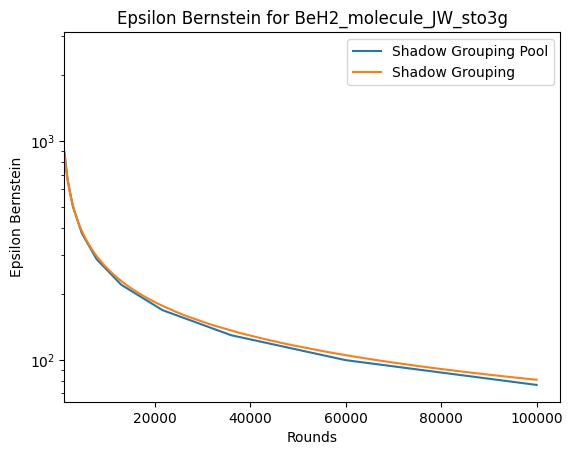

In [ ]:
#Epsilon Bernstein vs rounds plot
with open(bernsteinsavename, "r") as f:
    data = json.load(f)

plt.figure()

for method, values in data.items():
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method)

plt.xlabel("Rounds")
plt.ylabel("Epsilon Bernstein")
plt.title(f"Epsilon Bernstein for {savename}")
plt.legend()
plt.yscale('log')
plt.xlim(left=1000)
plt.show()

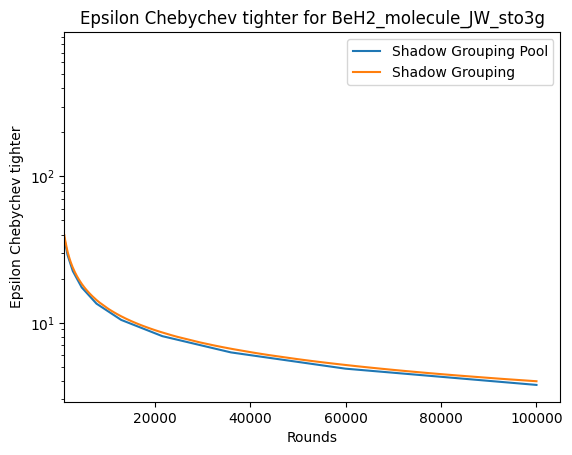

In [ ]:
#Chebychev tighter vs rounds plot
with open(chebyshevtightersavename, "r") as f:
    data = json.load(f)

plt.figure()

for method, values in data.items():
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method)

plt.xlabel("Rounds")
plt.ylabel("Epsilon Chebychev tighter")
plt.title(f"Epsilon Chebychev tighter for {savename}")
plt.legend()
plt.yscale('log')
plt.xlim(left=1000)
plt.show()

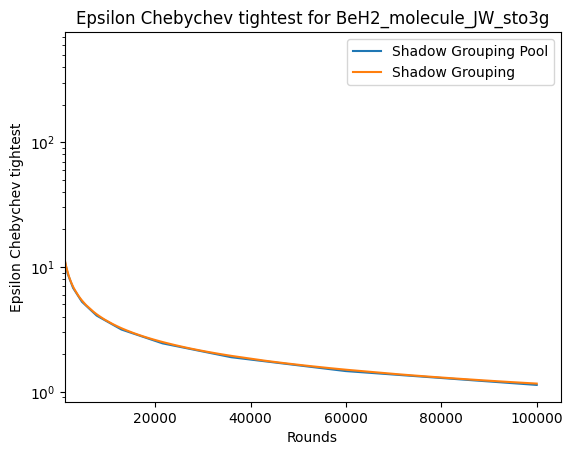

In [ ]:
#Chebychev tightest vs rounds plot
with open(chebyshevtightestsavename, "r") as f:
    data = json.load(f)

plt.figure()

for method, values in data.items():
    n = [v["n"] for v in values]
    eps = [v["epsilon"] for v in values]
    plt.plot(n, eps, label=method)

plt.xlabel("Rounds")
plt.ylabel("Epsilon Chebychev tightest")
plt.title(f"Epsilon Chebychev tightest for {savename}")
plt.legend()
plt.yscale('log')
plt.xlim(left=1000)
plt.show()

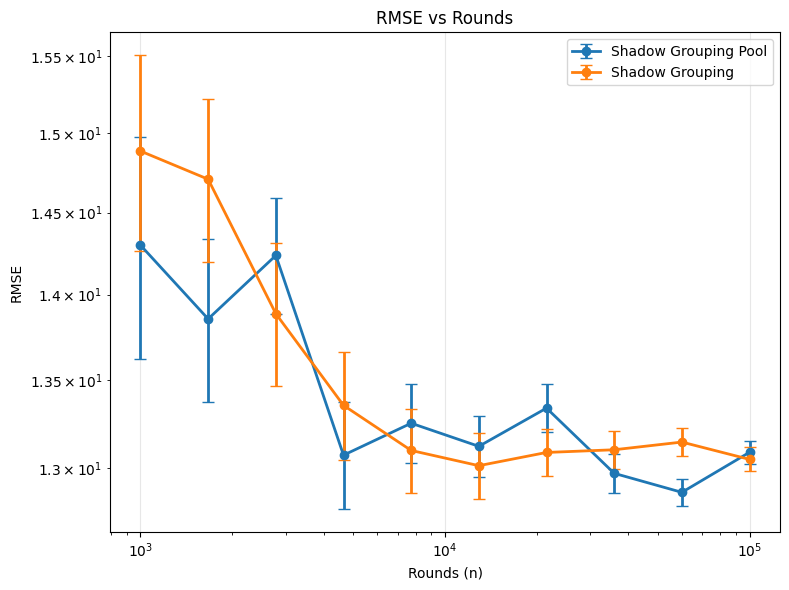

In [ ]:
with open(rmsesavename, "r") as f:
    data = json.load(f)

plt.figure(figsize=(8, 6))

for method, series in data.items():

    # safety: sort by n
    series = sorted(series, key=lambda d: d["n"])

    x = [d["n"] for d in series]
    y = [d["rmse"] for d in series]
    yerr = [d["std"] for d in series]

    plt.errorbar(
        x,
        y,
        yerr=yerr,
        marker='o',
        capsize=4,
        linewidth=2,
        label=method
    )

plt.xlabel("Rounds (n)")
plt.ylabel("RMSE")
plt.title("RMSE vs Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()